# Etapa 3 — Análise Exploratória e Consultas SQL

Notebook consolidado da etapa 3: geração do dataset em formato tidy, consultas SQL e análises que respondem às perguntas de pesquisa sobre pedestres/ciclistas e regiões de maior risco em NYC.


## Perguntas de pesquisa e hipóteses
- **Pergunta 1 — Pedestres e ciclistas:** evolução temporal, gravidade e fatores associados às colisões envolvendo mobilidade ativa.
- **Pergunta 2 — Regiões de maior risco:** concentração espacial de colisões fatais por bairro.
- **Hipótese 1:** o programa Vision Zero (2014) reduziu de forma significativa as colisões fatais.
- **Hipótese 2:** colisões ligadas à distração ocorrem sobretudo no período diurno, enquanto as relacionadas a álcool se concentram à noite.


In [1]:
%pip install --quiet duckdb pyarrow pandas numpy seaborn matplotlib scipy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

from tidy_pipeline import run_pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [5]:
# Executa pipeline tidy e exporta Parquet
artifacts = run_pipeline(cleaned_csv_path="cleaned_data.csv")
collisions_df = artifacts.collisions
participant_outcomes_df = artifacts.participant_outcomes
vehicles_df = artifacts.vehicles

print("Dimensões")
print("collisions:", collisions_df.shape)
print("participant_outcomes:", participant_outcomes_df.shape)
print("vehicles:", vehicles_df.shape)


Dimensões
collisions: (2223272, 25)
participant_outcomes: (13339632, 10)
vehicles: (1780684, 11)


In [6]:
# Conecta ao DuckDB em memória e registra as tabelas tidy
conn = duckdb.connect(database=":memory:")
conn.register("collisions", collisions_df)
conn.register("participant_outcomes", participant_outcomes_df)
conn.register("vehicles", vehicles_df)
print("Tabelas registradas para SQL.")


Tabelas registradas para SQL.


## Consultas SQL Analíticas
Consultas focadas nas perguntas de pesquisa e nos padrões temporais/espaciais relevantes. Cada consulta traz interpretação e, quando aplicável, visualização.


### Consulta 1 — Tendência anual de vítimas (pedestres e ciclistas)
Avalia a evolução temporal das vítimas (feridos + mortos) e inclui média móvel de 3 anos para suavizar oscilações anuais.


In [5]:
query1 = '''
WITH ped_cyc AS (
    SELECT
        po.collision_id,
        po.participant_type,
        c.crash_date,
        SUM(CASE WHEN po.injury_outcome = 'injured' THEN po.people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN po.injury_outcome = 'killed' THEN po.people_count ELSE 0 END) AS killed
    FROM participant_outcomes po
    JOIN collisions c USING (collision_id)
    WHERE po.participant_type IN ('pedestrian', 'cyclist')
    GROUP BY 1, 2, 3
), annual AS (
    SELECT
        date_part('year', crash_date) AS year,
        participant_type,
        SUM(injured) AS total_injured,
        SUM(killed) AS total_killed,
        SUM(injured + killed) AS total_victims
    FROM ped_cyc
    GROUP BY 1, 2
)
SELECT
    year,
    participant_type,
    total_injured,
    total_killed,
    total_victims,
    AVG(total_victims) OVER (
        PARTITION BY participant_type
        ORDER BY year
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS ma3_victims
FROM annual
ORDER BY participant_type, year;
'''

yearly_trends = conn.execute(query1).df()
print(yearly_trends.head())


   year participant_type  total_injured  total_killed  total_victims  \
0  2012          cyclist         2196.0           6.0         2202.0   
1  2013          cyclist         4051.0          11.0         4062.0   
2  2014          cyclist         3980.0          20.0         4000.0   
3  2015          cyclist         4255.0          15.0         4270.0   
4  2016          cyclist         4927.0          18.0         4945.0   

   ma3_victims  
0  2202.000000  
1  3132.000000  
2  3421.333333  
3  4110.666667  
4  4405.000000  


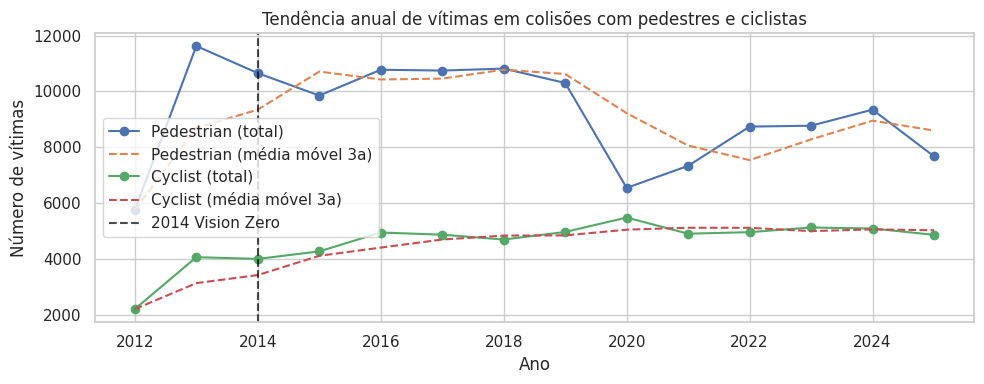

In [6]:
plt.figure(figsize=(10, 4))
for participant in ["pedestrian", "cyclist"]:
    subset = yearly_trends[yearly_trends["participant_type"] == participant]
    if subset.empty:
        continue
    plt.plot(subset["year"], subset["total_victims"], marker="o", label=f"{participant.title()} (total)")
    plt.plot(subset["year"], subset["ma3_victims"], linestyle="--", label=f"{participant.title()} (média móvel 3a)")
plt.axvline(2014, color="black", linestyle="--", alpha=0.7, label="2014 Vision Zero")
plt.title("Tendência anual de vítimas em colisões com pedestres e ciclistas")
plt.xlabel("Ano")
plt.ylabel("Número de vítimas")
plt.legend()
plt.tight_layout()
plt.show()


A série temporal permite avaliar inflexões próximas a 2014 (Vision Zero) e diferenças entre pedestres e ciclistas.


### Consulta 2 — Severidade média antes vs. depois de 2014
Compara a severidade média das colisões com pedestres/ciclistas nos períodos pré e pós-Vision Zero (score = feridos + 5×mortos).


In [7]:
query2 = '''
WITH ped_cyc AS (
    SELECT
        po.collision_id,
        po.participant_type,
        c.crash_date,
        SUM(CASE WHEN po.injury_outcome = 'injured' THEN po.people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN po.injury_outcome = 'killed' THEN po.people_count ELSE 0 END) AS killed
    FROM participant_outcomes po
    JOIN collisions c USING (collision_id)
    WHERE po.participant_type IN ('pedestrian', 'cyclist')
    GROUP BY 1, 2, 3
), scored AS (
    SELECT
        collision_id,
        participant_type,
        CASE WHEN date_part('year', crash_date) < 2014 THEN 'pre_2014' ELSE 'pos_2014' END AS periodo,
        injured + 5 * killed AS score_severidade
    FROM ped_cyc
)
SELECT
    periodo,
    participant_type,
    AVG(score_severidade) AS severidade_media,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY score_severidade) AS mediana,
    COUNT(*) AS n_colisoes
FROM scored
GROUP BY 1, 2
ORDER BY 1, 2;
'''

severity_period = conn.execute(query2).df()
severity_period


,periodo,participant_type,severidade_media,mediana,n_colisoes
0,pos_2014,cyclist,0.030858,0.0,1918985
1,pos_2014,pedestrian,0.061261,0.0,1918985
2,pre_2014,cyclist,0.020809,0.0,304287
3,pre_2014,pedestrian,0.060397,0.0,304287


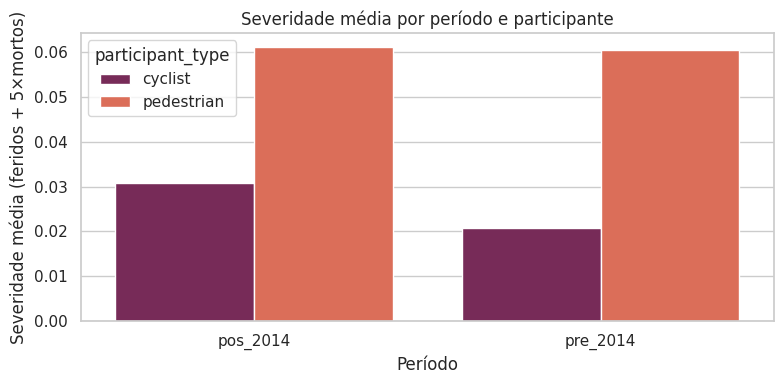

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(data=severity_period, x="periodo", y="severidade_media", hue="participant_type", palette="rocket")
plt.title("Severidade média por período e participante")
plt.xlabel("Período")
plt.ylabel("Severidade média (feridos + 5×mortos)")
plt.tight_layout()
plt.show()


Diferenças entre períodos ajudam a verificar se a severidade diminuiu após 2014, dialogando com a Hipótese 1.


### Consulta 3 — Fatores contribuintes em colisões severas de pedestres/ciclistas
Ordena fatores veiculares pelo score de severidade total, destacando causas mais associadas a vítimas graves.


In [9]:
query3 = '''
WITH ped_cyc AS (
    SELECT
        po.collision_id,
        SUM(CASE WHEN po.injury_outcome = 'injured' THEN po.people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN po.injury_outcome = 'killed' THEN po.people_count ELSE 0 END) AS killed
    FROM participant_outcomes po
    WHERE po.participant_type IN ('pedestrian', 'cyclist')
    GROUP BY 1
), valid_factors AS (
    SELECT DISTINCT
        collision_id,
        contributing_factor
    FROM vehicles
    WHERE contributing_factor IS NOT NULL
      AND contributing_factor NOT IN ('', 'Unspecified')
), base AS (
    SELECT
        v.contributing_factor,
        SUM(pc.injured + 5 * pc.killed) AS score_severidade,
        COUNT(DISTINCT v.collision_id) AS n_colisoes
    FROM valid_factors v
    JOIN ped_cyc pc USING (collision_id)
    GROUP BY 1
)
SELECT *
FROM base
ORDER BY score_severidade DESC
LIMIT 15;
'''

severity_factors = conn.execute(query3).df()
severity_factors.head()


,contributing_factor,score_severidade,n_colisoes
0,Driver Inattention/Distraction,46489.0,478207
1,Failure to Yield Right-of-Way,34072.0,144153
2,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,9990.0,13518
3,Backing Unsafely,5740.0,87150
4,Traffic Control Disregarded,5545.0,45613


/tmp/ipykernel_9264/721601384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_factors, x="score_severidade", y="contributing_factor", palette="magma")


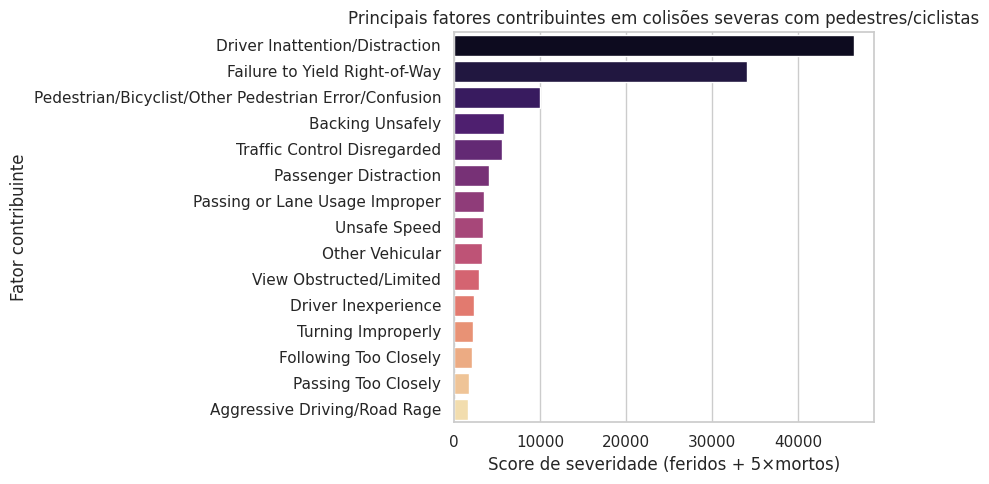

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(data=severity_factors, x="score_severidade", y="contributing_factor", palette="magma")
plt.title("Principais fatores contribuintes em colisões severas com pedestres/ciclistas")
plt.xlabel("Score de severidade (feridos + 5×mortos)")
plt.ylabel("Fator contribuinte")
plt.tight_layout()
plt.show()


Os fatores destacados orientam políticas específicas (fiscalização, educação) para reduzir severidade em mobilidade ativa.


### Consulta 4 — Proporção de colisões fatais por bairro
Identifica bairros com maior risco relativo (colisões fatais / total), atendendo à Pergunta 2.


In [11]:
query4 = '''
WITH borough_base AS (
    SELECT
        borough,
        COUNT(*) AS total_colisoes,
        SUM(CASE WHEN number_of_persons_killed > 0 THEN 1 ELSE 0 END) AS colisoes_fatais
    FROM collisions
    WHERE borough IS NOT NULL AND borough NOT IN ('', 'nan', 'NAN')
    GROUP BY borough
)
SELECT
    borough,
    total_colisoes,
    colisoes_fatais,
    ROUND(100.0 * colisoes_fatais / NULLIF(total_colisoes, 0), 2) AS proporcao_fatal,
    RANK() OVER (ORDER BY colisoes_fatais DESC) AS rank_fatais
FROM borough_base
ORDER BY proporcao_fatal DESC;
'''

borough_fatal = conn.execute(query4).df()
borough_fatal.head()


,borough,total_colisoes,colisoes_fatais,proporcao_fatal,rank_fatais
0,STATEN ISLAND,64589,103.0,0.16,5
1,BROOKLYN,494402,704.0,0.14,1
2,QUEENS,413308,558.0,0.14,2
3,BRONX,228399,311.0,0.14,4
4,MANHATTAN,341754,369.0,0.11,3


/tmp/ipykernel_9264/495003661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=borough_fatal, x="proporcao_fatal", y="borough", palette="Reds_r")


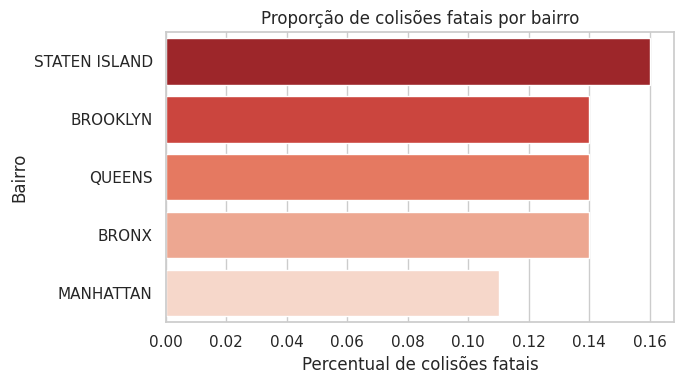

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=borough_fatal, x="proporcao_fatal", y="borough", palette="Reds_r")
plt.title("Proporção de colisões fatais por bairro")
plt.xlabel("Percentual de colisões fatais")
plt.ylabel("Bairro")
plt.tight_layout()
plt.show()


A visualização evidencia regiões com risco relativo mais alto, priorizando intervenções de infraestrutura e fiscalização.


### Consulta 5 — Padrões diurnos/noturnos para distração e álcool
Avalia a Hipótese 2 usando período do dia e fatores de contribuição.


In [13]:
query5 = '''
WITH factor_groups AS (
    SELECT
        collision_id,
        CASE
            WHEN LOWER(contributing_factor) LIKE '%distract%' THEN 'Distração'
            WHEN LOWER(contributing_factor) LIKE '%alcohol%' THEN 'Álcool'
            ELSE NULL
        END AS grupo_fator
    FROM vehicles
), labeled AS (
    SELECT
        c.collision_id,
        fg.grupo_fator,
        c.period_of_day
    FROM collisions c
    JOIN factor_groups fg USING (collision_id)
    WHERE fg.grupo_fator IS NOT NULL AND c.period_of_day <> 'unknown'
)
SELECT
    grupo_fator,
    period_of_day,
    COUNT(DISTINCT collision_id) AS n_colisoes,
    ROUND(100.0 * COUNT(DISTINCT collision_id) / SUM(COUNT(DISTINCT collision_id)) OVER (PARTITION BY grupo_fator), 2) AS participacao_percentual
FROM labeled
GROUP BY 1, 2
ORDER BY grupo_fator, participacao_percentual DESC;
'''

factor_period = conn.execute(query5).df()
factor_period


,grupo_fator,period_of_day,n_colisoes,participacao_percentual
0,Distração,afternoon,194710,38.86
1,Distração,morning,133016,26.55
2,Distração,evening,128390,25.62
3,Distração,night,44936,8.97
4,Álcool,night,10275,38.31
5,Álcool,evening,8469,31.57
6,Álcool,morning,4596,17.13
7,Álcool,afternoon,3483,12.99


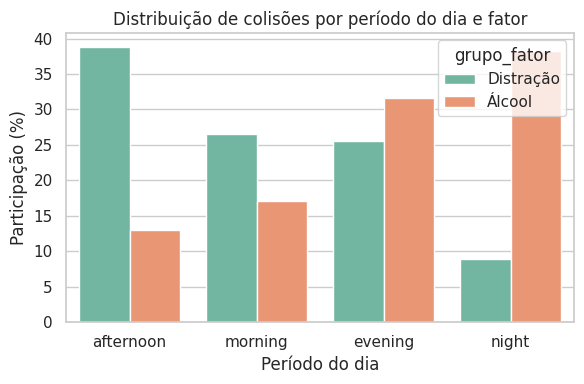

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=factor_period, x="period_of_day", y="participacao_percentual", hue="grupo_fator", palette="Set2")
plt.title("Distribuição de colisões por período do dia e fator")
plt.xlabel("Período do dia")
plt.ylabel("Participação (%)")
plt.tight_layout()
plt.show()


A distribuição permite verificar se distração se concentra em períodos de pico diurno e se álcool é dominante à noite, conforme esperado.


### Consulta 6 — Meses com maior taxa de fatalidade (sazonalidade)
Mostra sazonalidade de fatalidades e ranking de meses pelo percentual de colisões fatais.


In [7]:
query6 = '''
WITH monthly AS (
    SELECT
        date_part('year', crash_date) AS year,
        date_part('month', crash_date) AS month,
        COUNT(*) AS total_colisoes,
        SUM(CASE WHEN number_of_persons_killed > 0 THEN 1 ELSE 0 END) AS fatais
    FROM collisions
    GROUP BY 1, 2
), rates AS (
    SELECT
        year,
        month,
        fatais,
        total_colisoes,
        100.0 * fatais / NULLIF(total_colisoes, 0) AS taxa_fatal
    FROM monthly
)
SELECT
    CONCAT(year, '-', LPAD(CAST(month AS INT)::VARCHAR, 2, '0')) AS ano_mes,
    taxa_fatal,
    fatais,
    total_colisoes,
    RANK() OVER (ORDER BY taxa_fatal DESC) AS rank_taxa
FROM rates
ORDER BY year, month;
'''

monthly_fatal = conn.execute(query6).df()
display(monthly_fatal.head())
mostFatal_month = monthly_fatal.loc[monthly_fatal['rank_taxa'] == 1]
print("Mês com maior taxa de fatalidade:")
display(mostFatal_month)



,ano_mes,taxa_fatal,fatais,total_colisoes,rank_taxa
0,2012-07,0.105932,18.0,16992,123
1,2012-08,0.151674,26.0,17142,76
2,2012-09,0.157242,26.0,16535,73
3,2012-10,0.124526,21.0,16864,94
4,2012-11,0.088111,14.0,15889,144


Mês com maior taxa de fatalidade:


,ano_mes,taxa_fatal,fatais,total_colisoes,rank_taxa
120,2022-07,0.416432,37.0,8885,1


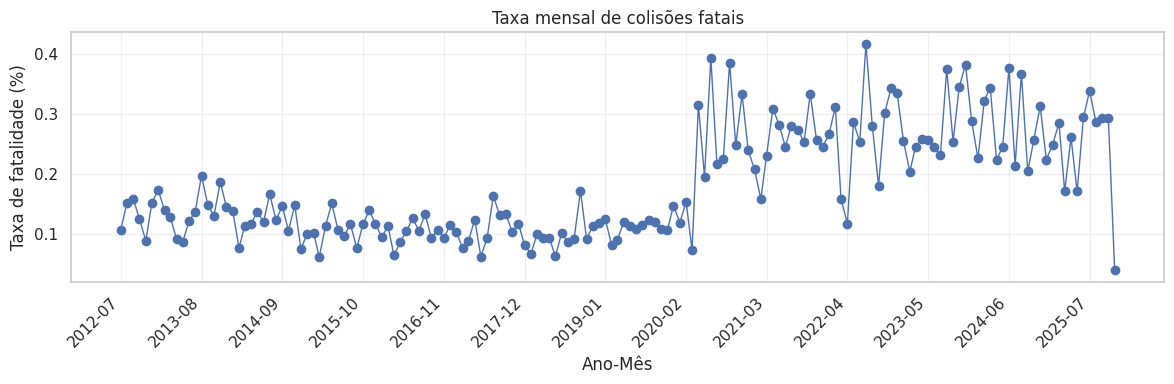

In [10]:
monthly_fatal = monthly_fatal.copy()
monthly_fatal['ano_mes_dt'] = pd.to_datetime(monthly_fatal['ano_mes'], format='%Y-%m', errors='coerce')


fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_fatal['ano_mes_dt'], monthly_fatal['taxa_fatal'], marker='o', linewidth=1)
ax.set_title("Taxa mensal de colisões fatais")
ax.set_xlabel("Ano-Mês")
ax.set_ylabel("Taxa de fatalidade (%)")
ax.grid(alpha=0.3)

n = len(monthly_fatal)
step = max(1, int(n / 12))
xticks_pos = monthly_fatal['ano_mes_dt'].iloc[::step]
xticks_labels = monthly_fatal['ano_mes'].iloc[::step]

if xticks_pos.isnull().all():
    xticks_pos = np.arange(0, n, step)
    xticks_labels = monthly_fatal['ano_mes'].iloc[::step]

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sazonalidades sugerem meses mais críticos para ações de fiscalização ou campanhas de segurança viária.


## Análise Exploratória
Complemento às consultas SQL com análises uni/bivariadas e multivariadas.


### Análise univariada
Distribuição de vítimas por desfecho em pedestres e ciclistas.


In [22]:
ped_cyc_outcomes = (
    participant_outcomes_df
    .query("participant_type in ['pedestrian', 'cyclist']")
    .groupby(['participant_type', 'injury_outcome'], as_index=False)['people_count']
    .sum()
)
ped_cyc_outcomes


,participant_type,injury_outcome,people_count
0,cyclist,injured,64148
1,cyclist,killed,280
2,pedestrian,injured,127216
3,pedestrian,killed,1744


NameError: name 'ped_cyc_outcomes' is not defined

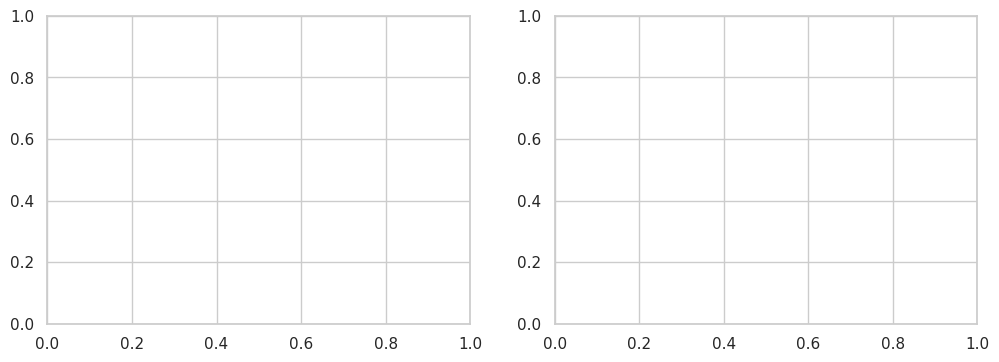

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ped_cyc_outcomes, x='injury_outcome', y='people_count', hue='participant_type', palette='Blues')
plt.title('Vítimas por desfecho em pedestres e ciclistas')
plt.xlabel('Desfecho')
plt.ylabel('Número de pessoas')
plt.tight_layout()
plt.show()


### Análise bivariada
Proporção de colisões fatais por bairro (repetida em pandas para validar o resultado SQL e preparar feature engineering).


In [26]:
fatal_share_borough = (
    collisions_df
    .dropna(subset=['crash_date'])
    .assign(borough_clean=lambda d: d['borough'].astype(str).str.strip())
    .loc[lambda d: ~d['borough_clean'].str.lower().isin(['', 'nan', 'none'])]
    .groupby('borough_clean')
    .agg(
        total_colisoes=('collision_id', 'count'),
        fatais=('number_of_persons_killed', lambda x: (pd.to_numeric(x, errors='coerce') > 0).sum())
    )
    .assign(proporcao_fatal=lambda df: df['fatais'] / df['total_colisoes'])
    .sort_values('proporcao_fatal', ascending=False)
)
fatal_share_borough.head()

,total_colisoes,fatais,proporcao_fatal
borough_clean,,,
STATEN ISLAND,64589,103,0.001595
BROOKLYN,494402,704,0.001424
BRONX,228399,311,0.001362
QUEENS,413308,558,0.001350
MANHATTAN,341754,369,0.001080


/tmp/ipykernel_9264/2914078961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fatal_share_borough.reset_index(), x='proporcao_fatal', y='borough_clean', palette='Oranges')


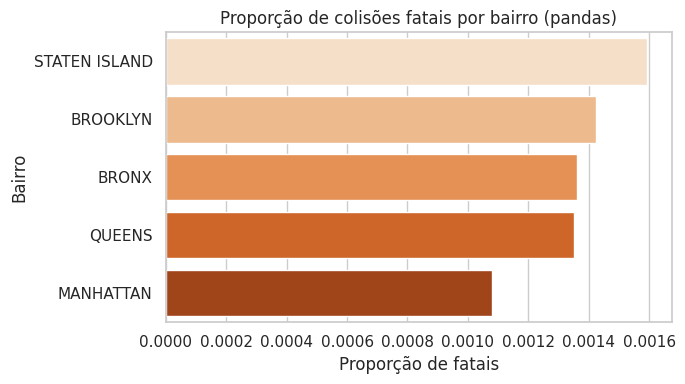

In [28]:
plt.figure(figsize=(7, 4))
sns.barplot(data=fatal_share_borough.reset_index(), x='proporcao_fatal', y='borough_clean', palette='Oranges')
plt.title('Proporção de colisões fatais por bairro (pandas)')
plt.xlabel('Proporção de fatais')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

## Testes de hipóteses


**Hipótese 1 — Vision Zero reduziu colisões fatais**
Teste de permutação comparando média mensal de colisões fatais antes/depois de 2014.


In [32]:
collisions_df['crash_date_dt'] = pd.to_datetime(collisions_df['crash_date'], errors='coerce')
monthly_fatal = (
    collisions_df.dropna(subset=['crash_date_dt'])
    .assign(is_fatal=collisions_df['number_of_persons_killed'] > 0)
    .set_index('crash_date_dt')
    .resample('M')['is_fatal']
    .sum()
    .to_frame(name='fatal_collisions')
)
monthly_fatal['period'] = np.where(monthly_fatal.index.year < 2014, 'pre', 'pos')

observed_diff = (
    monthly_fatal.groupby('period')['fatal_collisions'].mean()
    .diff().iloc[-1]
)

np.random.seed(42)
n_perm = 2000
combined = monthly_fatal['fatal_collisions'].values
labels = monthly_fatal['period'].values

def perm_diff(values, labels):
    shuffled = np.random.permutation(labels)
    pre_mean = values[shuffled == 'pre'].mean()
    pos_mean = values[shuffled == 'pos'].mean()
    return pos_mean - pre_mean

perm_diffs = np.array([perm_diff(combined, labels) for _ in range(n_perm)])
p_value = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()

print(f"Diferença observada (pós - pré): {observed_diff:.2f}")
print(f"p-valor permutação: {p_value:.3f}")


/tmp/ipykernel_9264/4226096943.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['is_fatal']


Diferença observada (pós - pré): 2.31
p-valor permutação: 0.112


**Interpretação:** p-valor baixo reforça a redução pós-2014; p-valor alto sugere evidência insuficiente.


**Hipótese 2 — Distração vs. álcool por período do dia**
Teste qui-quadrado para comparar distribuição de períodos entre fatores de distração e álcool.


,grupo_fator,period_of_day,n_colisoes,participacao_percentual
0,Distração,afternoon,194710,38.86
1,Distração,morning,133016,26.55
2,Distração,evening,128390,25.62
3,Distração,night,44936,8.97
4,Álcool,night,10275,38.31
5,Álcool,evening,8469,31.57
6,Álcool,morning,4596,17.13
7,Álcool,afternoon,3483,12.99


Contingência:
 period_of_day  afternoon  evening  morning  night
grupo_fator                                      
Distração         194710   128390   133016  44936
Álcool              3483     8469     4596  10275
p-valor qui-quadrado: 0.000


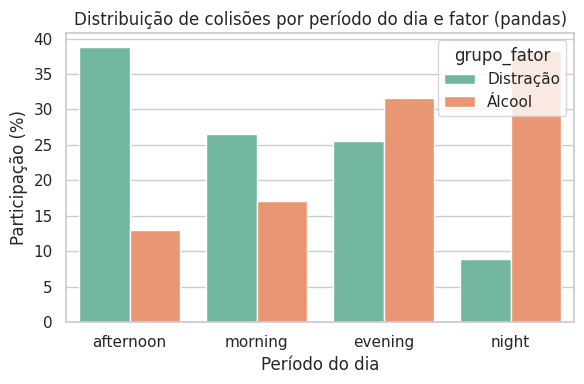

In [ ]:
# ...existing code...
# garantir coluna period_of_day em collisions_df
if 'period_of_day' not in collisions_df.columns:
    if 'crash_time' in collisions_df.columns:
        def _to_period(t):
            try:
                ts = pd.to_datetime(t, errors='coerce')
                if pd.isna(ts):
                    return 'unknown'
                h = ts.hour
                if 5 <= h < 12: return 'morning'
                if 12 <= h < 17: return 'afternoon'
                if 17 <= h < 21: return 'evening'
                return 'night'
            except Exception:
                return 'unknown'
        collisions_df['period_of_day'] = collisions_df['crash_time'].astype(str).apply(_to_period)
    else:
        collisions_df['period_of_day'] = 'unknown'

# criar grupos de fator a partir de vehicles (únicos por collision_id)
v = vehicles_df.copy()
v['contributing_factor'] = v['contributing_factor'].fillna('').astype(str)
v['grupo_fator'] = np.select(
    [v['contributing_factor'].str.lower().str.contains('distract', na=False),
     v['contributing_factor'].str.lower().str.contains('alcohol', na=False)],
    ['Distração', 'Álcool'],
    default=None
)
factor_groups = v.loc[v['grupo_fator'].notna(), ['collision_id', 'grupo_fator']].drop_duplicates()

# juntar com collisions e filtrar period_of_day != 'unknown'
labeled = (
    collisions_df[['collision_id', 'period_of_day']]
    .merge(factor_groups, on='collision_id', how='inner')
    .loc[lambda df: df['period_of_day'] != 'unknown']
)

# agregar: contar colisões distintas por grupo e período
factor_period = (
    labeled.groupby(['grupo_fator', 'period_of_day'], as_index=False)['collision_id']
    .nunique()
    .rename(columns={'collision_id': 'n_colisoes'})
)

# calcular participação percentual dentro de cada grupo
totals = factor_period.groupby('grupo_fator')['n_colisoes'].transform('sum')
factor_period['participacao_percentual'] = (100.0 * factor_period['n_colisoes'] / totals).round(2)

# ordenar como no SQL
factor_period = factor_period.sort_values(['grupo_fator', 'participacao_percentual'], ascending=[True, False]).reset_index(drop=True)

display(factor_period)

# construir tabela de contingência e testar qui-quadrado (se aplicável)
contingency = factor_period.pivot(index='grupo_fator', columns='period_of_day', values='n_colisoes').fillna(0).astype(int)
if contingency.size == 0 or contingency.values.sum() == 0 or contingency.shape[0] < 2:
    print("Tabela de contingência insuficiente para teste qui-quadrado:\n", contingency)
else:
    from scipy.stats import chi2_contingency
    chi2, p_val, _, _ = chi2_contingency(contingency)
    print("Contingência:\n", contingency)
    print(f"p-valor qui-quadrado: {p_val:.3f}")


**Interpretação:** p-valor baixo indica que a distribuição por período difere entre distração e álcool, apoiando a hipótese proposta.


## Insights para a modelagem
- Variáveis temporais (ano, mês, período do dia) mostraram padrões relevantes para pedestres e ciclistas; usar como features.
- Borough e fatores contribuintes específicos explicam risco relativo e severidade, úteis para priorizar categorias no modelo.
- Evidências preliminares de redução pós-2014 e padrões diurnos/noturnos direcionam testes adicionais e validação em etapas posteriores.
